# Mapping

In [1]:
from pathlib import Path
import sys
import os

ROOT = Path(os.getcwd())

# if notebook is in notebooks/, go up one level
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

In [2]:
import pandas as pd

In [3]:
data = pd.read_pickle(DATA/'ml_datasets/all_raw_samples.pkl')

In [4]:
features = pd.read_pickle(DATA/'ml_datasets/L2_DATASET_mapping.pkl')


target_cols =  ['EX_o2_e','EX_glc__D_e', 'EX_ac_e', 'EX_lcts_e', 'EX_glyc_e', 'EX_arg__L_e', 'EX_nh4_e', 'EX_no3_e']
target = data[target_cols]

**Transforming target**

In [5]:
import numpy as np
from sklearn.preprocessing import normalize

In [6]:
target_uptake = target.clip(upper=0).abs()

target_log = np.log1p(target_uptake)
target_norm = normalize(target_log, norm='l2', axis=1)

target_trans = pd.DataFrame(
    target_norm,
    index=target.index,
    columns=target.columns
)

target_trans['source'] = data['source'].values

## 1. Euclidean distances

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import pairwise_distances
color_map = sns.color_palette("GnBu", as_cmap=True)

In [8]:
X = features.iloc[:, :5]
Y = target_trans.drop(columns='source')

### Distance-distance plot

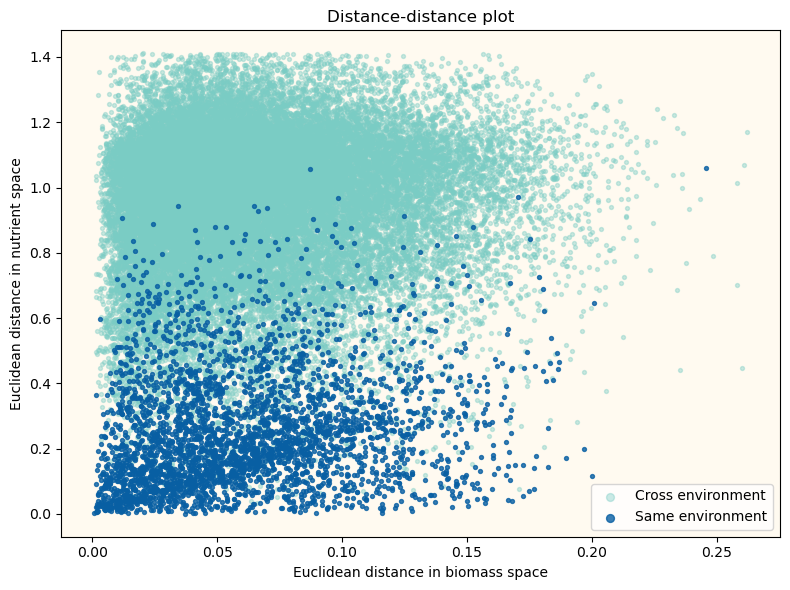

In [32]:
# ================================================================
# PER-SAMPLE DISTANCE-DISTANCE PLOT
# ================================================================
labels = target_trans['source'].values

# ---- compute pairwise distances ----
DX = pairwise_distances(X, metric="euclidean")
DY = pairwise_distances(Y, metric="euclidean")

# ---- upper triangle ----
i, j = np.triu_indices_from(DX, k=1)
dx = DX[i, j]
dy = DY[i, j]
same = labels[i] == labels[j]

# ---- subsample ----
max_pairs = 40000
if len(dx) > max_pairs:
    idx = np.random.choice(len(dx), size=max_pairs, replace=False)
    dx = dx[idx]
    dy = dy[idx]
    same = same[idx]

# ---- plot ----
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(dx[~same], dy[~same], s=8, alpha=0.4, label="Cross environment", color=color_map(0.5))
ax.scatter(dx[same],  dy[same],  s=8, alpha=0.8, label="Same environment", color=color_map(0.9))
ax.legend(markerscale=2)
ax.set_xlabel("Euclidean distance in biomass space")
ax.set_ylabel("Euclidean distance in nutrient space")
ax.set_title("Distance-distance plot")
ax.set_facecolor('floralwhite')
plt.tight_layout()
plt.show()

### Heatmap

**Centroids**

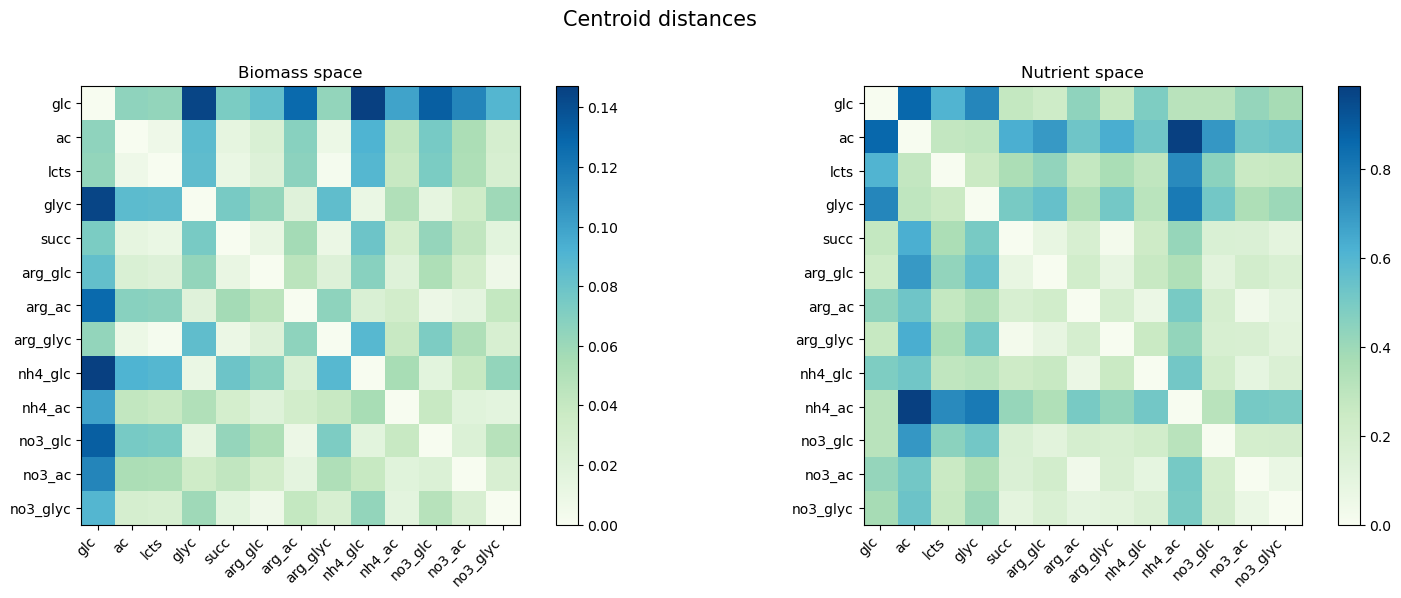

In [34]:
# ================================================================
# CENTROID DISTANCE HEATMAPS (biomass space vs nutrient space)
# ================================================================
labels = target_trans['source'].values

# ---- compute centroids ----
unique_envs = np.unique(labels)
X_centroids = np.array([X[labels == env].mean(axis=0) for env in unique_envs])
Y_centroids = np.array([Y[labels == env].mean(axis=0) for env in unique_envs])

# ---- define custom ordering ----
env_order = ['glc', 'ac', 'lcts', 'glyc', 'succ', 'arg_glc', 'arg_ac', 'arg_glyc',
             'nh4_glc', 'nh4_ac', 'no3_glc', 'no3_ac', 'no3_glyc']
order_idx = [list(unique_envs).index(env) for env in env_order]

DX_ordered = DX[np.ix_(order_idx, order_idx)]
DY_ordered = DY[np.ix_(order_idx, order_idx)]

# ---- plot side by side ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, D, title in zip(axes, [DX_ordered, DY_ordered], ["Biomass space", "Nutrient space"]):
    im = ax.imshow(D, cmap="GnBu")
    ax.set_xticks(range(len(env_order)))
    ax.set_yticks(range(len(env_order)))
    ax.set_xticklabels(env_order, rotation=45, ha="right")
    ax.set_yticklabels(env_order)
    ax.set_title(f"{title}")
    plt.colorbar(im, ax=ax)

plt.suptitle('Centroid distances', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()